10 4183


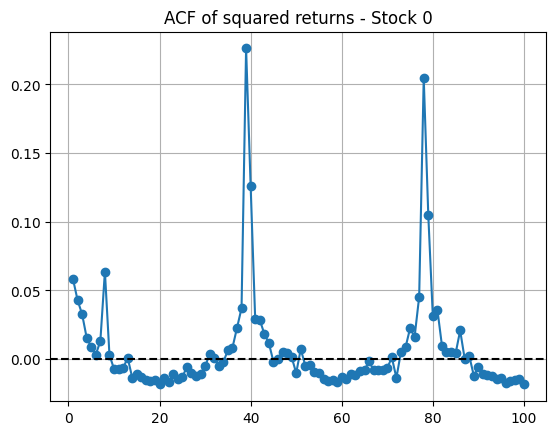

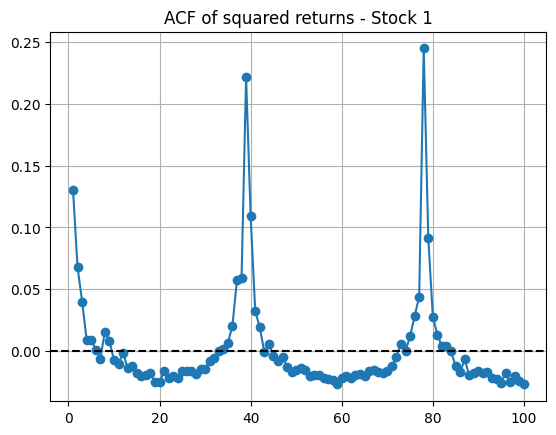

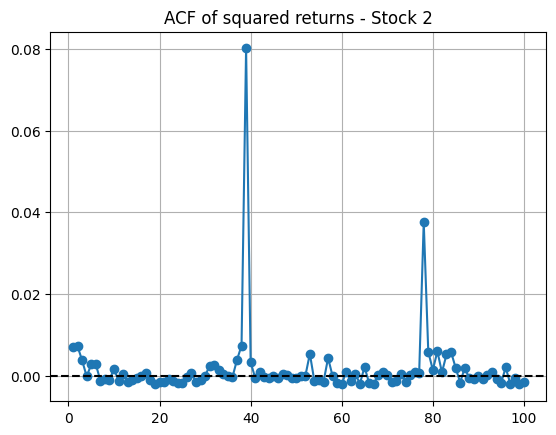

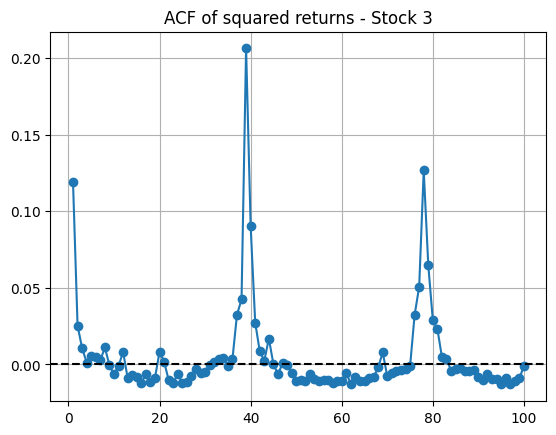

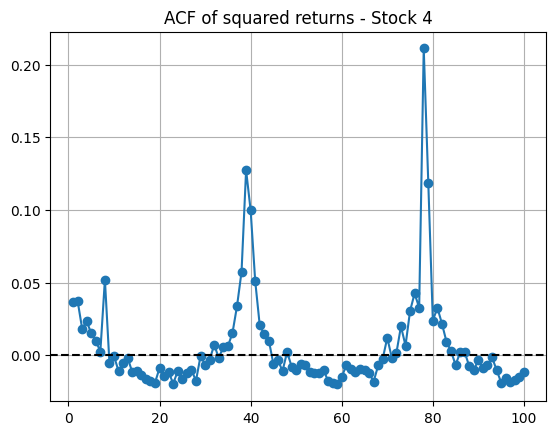

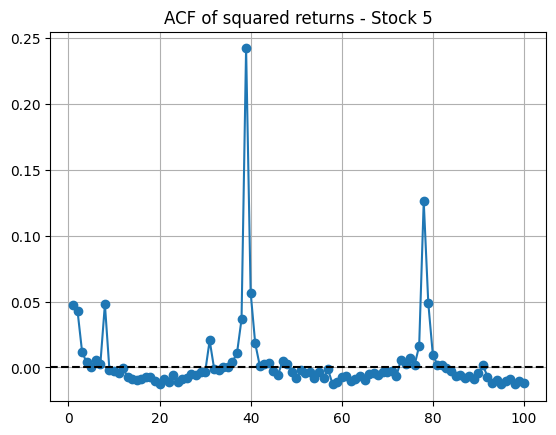

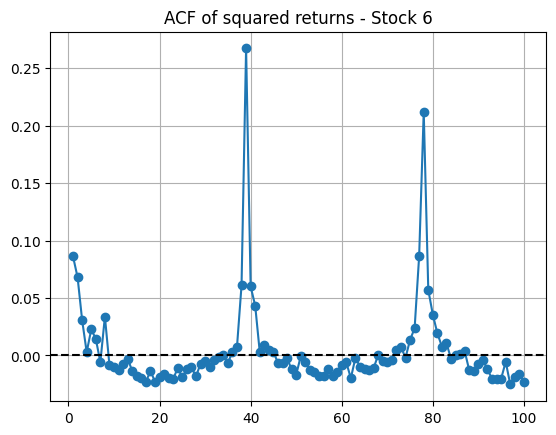

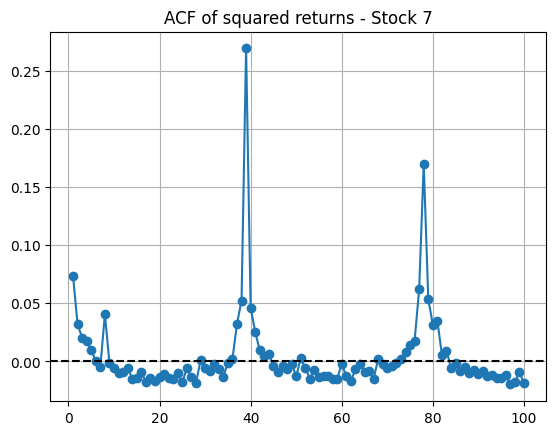

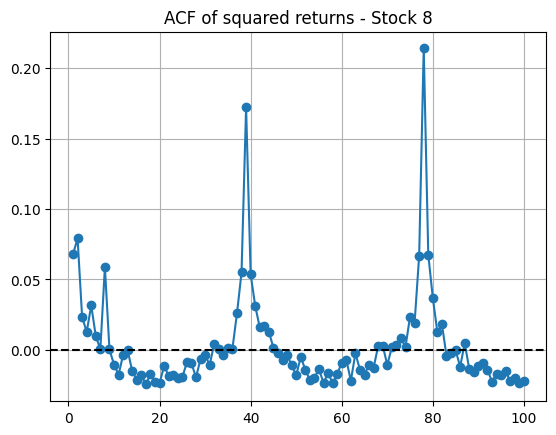

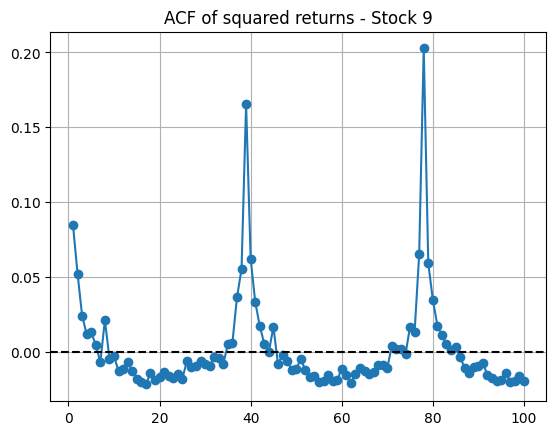

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf


seed=0
np.random.seed(seed)
data_file = "data/data.xlsx"
stock_prices = pd.read_excel(data_file, index_col=0, parse_dates=True)
stock_prices.index = pd.to_datetime(stock_prices.index) #use the first column as time index 
N = len(stock_prices.iloc[0]) 
original_T = len(stock_prices)
frequency_step=10

stocks_returns = []
for i in range(frequency_step, original_T, frequency_step):
    stocks_returns.append(np.log(stock_prices.iloc[i]/stock_prices.iloc[i-frequency_step]))

T = len(stocks_returns)
stocks_returns = np.vstack(stocks_returns)   #first column is referred to first stock, second column to second stock, ...

print(N, T)

gt_autocorr_continuous = np.zeros((100, N))
for col in range(N): 
    column = stocks_returns[:, col] 
    gt_autocorr_continuous[:,col] = acf(column**2, nlags=100, fft=False)[1:]
    plt.figure()
    plt.plot(range(1,100+1), gt_autocorr_continuous[:,col], marker='o')
    plt.title(f"ACF of squared returns - Stock {col}")
    plt.axhline(0, color='black', linestyle='--')
    plt.grid(True)
    plt.show()